# 37 - Daughter momentum-grid convergence at large f̃

nb36 (section 3) found that the default strategy-5 grid, `accdm_q_bins_per_decade = 50`, is not converged once
the daughter is a large share of the dark matter. Against 200/decade, TT is off by 3% at f̃ = 0.5 and 10% at
f̃ = 0.99 (10¹² GeV), and the error falls slowly at 10¹² GeV (order ≈ 0.7) but fast at 10¹⁶ GeV (order ≈ 3).
This notebook answers two questions before anything is changed.

- **1. Does it matter for the data?** Δχ² of each grid against a 400/decade reference on a (mass, f̃) grid, set
  against the accDM signal and the f̃ the fixed-mass chains actually reach.
- **2. What limits convergence?** At two points, the same grid sequence with smooth births, plus single changes
  of the integration tolerance, of a_min and of the daughter hierarchy length. If one of them restores fast
  convergence, the fix is that setting, not more bins.

Section 0 counts, without CLASS, how many grid nodes fall where daughters are born.

- **Settings:** the fixed-mass CONNECT chains (`connect/new`: κ = 12.1, a_t = 0.133, strategy 5, no DE sink),
  ΛCDM best fit of the 10¹⁴ GeV chain, fixed ω_dm,tot; f̃ and the daughter precision change.
- **Δχ²:** the nb32/nb33 approximation (Planck-like CMB, 2.5% lensing amplitude, 1% DESI-like BAO, ΛCDM
  parameters fixed): a sensitivity scale, not a likelihood. Tolerance 0.1 as in nb33.
- **Reference:** 400 bins/decade; 800 vs 400 at the two hardest points estimates its own error.

Runtime about 2 h, mostly the 400/800-per-decade runs (about 2 and 3 min each; 6 min with `l_max_ncdm = 50`). Runs are cached in
`37_cache.pkl`; delete it after rebuilding CLASS.

In [1]:
import json
import multiprocessing as mp
import pickle
import queue
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from classy import Class

import figkit as fk

fk.use('quick')


def find_root(start=None):
    start = Path.cwd() if start is None else start
    for d in [start, *start.parents]:
        if (d/'chains'/'fixed_masses').is_dir():
            return d
    raise FileNotFoundError('no chains/fixed_masses above {}'.format(start))


def read_bestfit(path):
    with open(path) as fh:
        names = [s.strip() for s in fh.readline().lstrip('#').split(',')]
        values = [float(v) for v in fh.readline().split()]
    return dict(zip(names, values))


def show(df, formats):
    """display df with per-column format strings; missing values as '-'."""
    out = df.copy().astype(object)
    for col, f in formats.items():
        out[col] = [('-' if pd.isna(v) else f.format(v)) for v in df[col]]
    display(out)


CHAINS = find_root()/'chains'/'fixed_masses'/'connect'/'new'
BF = read_bestfit(CHAINS/'14'/'14.bestfit')
LCDM = {k: BF[k] for k in ('omega_b', 'H0', 'ln10^{10}A_s', 'n_s', 'tau_reio')}
OMEGA_DM_TOT = BF['omega_dm_tot']
KAPPA, A_T = 12.1, 0.133

# extra_input of the fixed-mass CONNECT emulators (as nb36); mass, f_tilde and precision are set per run
SETTINGS = {'k_pivot': 0.05, 'lensing': 'yes', 'N_ur': 2.0308, 'N_ncdm': 2, 'deg_ncdm': '1, 1',
            'm_ncdm': '0.06, 0.01', 'T_ncdm': '0.71611, 1.0', 'ncdm_quadrature_strategy': '0, 5',
            'ncdm_fluid_approximation': 3, 'kappa_acc': KAPPA, 'a_t_acc': A_T,
            'vary_Gamma_acc': 'yes', 'gauge': 'synchronous', 'reionization_z_start_max': 80,
            'evolver': 0, 'P_k_max_1/Mpc': 1., 'output': 'tCl,pCl,lCl,mPk', 'l_max_scalars': 2508,
            'omega_dm_tot': OMEGA_DM_TOT}


def per_decade(n):
    return {'accdm_q_bins_per_decade': n}


BINS = [50, 100, 200, 400]                    # 50 is the default
REF = 400
F_NULL = 1e-6                                 # signal reference; accDM needs f > 0
print('fiducial omega_dm_tot = {:.5f}'.format(OMEGA_DM_TOT))


def chain_f95(directory, burn_in=0.3):
    """95% upper limit on f_tilde of one connect/new chain, as sampled (flat omega_dm_tot, f_acc)."""
    names = [line.split()[0] for line in open(next(directory.glob('*_.paramnames')))]
    blocks = []
    for path in sorted(directory.glob('*__*.txt')):
        block = pd.read_csv(path, sep=r'\s+', header=None, comment='#').to_numpy()
        blocks.append(block[int(burn_in*len(block)):])
    data = np.vstack(blocks)
    w, f = data[:, 0], data[:, 2 + names.index('f_acc')]
    ft = f/(1 + f)
    order = np.argsort(ft)
    cdf = np.cumsum(w[order])
    return float(np.interp(0.95*cdf[-1], cdf, ft[order]))


F95 = {float(d.name): chain_f95(d) for d in CHAINS.iterdir() if d.is_dir() and d.name.replace('.', '').isdigit()
       and any(d.glob('*__*.txt'))}
print('chain 95% f_tilde:', ', '.join('{:g}: {:.3f}'.format(m, F95[m]) for m in sorted(F95)))

/opt/homebrew/Caskroom/miniforge/base/envs/accDM/lib/python3.12/site-packages/figkit/style.py:132: RuntimeWarning: text.usetex requested but latex, dvipng not found on PATH; falling back to matplotlib mathtext. Install TeX Live or MiKTeX (and dvipng) for identical output, or pass usetex=False to silence this.
  usetex = bool(usetex) and latex_available()


fiducial omega_dm_tot = 0.11771
chain 95% f_tilde: 11: 0.007, 12: 0.012, 13: 0.017, 14: 0.026, 15: 0.079, 15.301: 0.122, 15.699: 0.302, 16: 0.844, 16.301: 0.900, 16.699: 0.904, 17: 0.905, 17.301: 0.905, 17.699: 0.904, 18: 0.889


## 0. Where the nodes are

Strategy 5 spreads its nodes evenly in ln a_q over [a_min, 1], where a_min is set by a born fraction of
`accdm_q_number_tol` = 10⁻⁶. With κ = 12.1 the births are concentrated around a_t; this counts the nodes inside
the central 98% and 80% of births, using the born fraction F(a) of `background_acc_born_fraction`.

In [2]:
def born_fraction(a):
    """F(a) as in background_acc_born_fraction."""
    return 1 - (1 - a**KAPPA)/(1 + (a/A_T)**KAPPA)


def a_min(eps=1e-6):
    """background_acc_a_min: bisection in ln a."""
    lo, hi = np.log(1e-14), 0.0
    for _ in range(200):
        mid = 0.5*(lo + hi)
        lo, hi = (mid, hi) if born_fraction(np.exp(mid)) < eps else (lo, mid)
    return np.exp(lo)


A_MIN = a_min()
DECADES = np.log10(1/A_MIN)
lna_fine = np.linspace(np.log(A_MIN), 0, 100001)
F_fine = born_fraction(np.exp(lna_fine))
birth = {q: np.exp(np.interp(q, F_fine, lna_fine)) for q in (0.01, 0.1, 0.5, 0.9, 0.99)}
print('a_min = {:.4f} ({:.2f} decades); births: 1% at a = {:.3f}, 10% at {:.3f}, 50% at {:.3f}, 90% at {:.3f}, '
      '99% at {:.3f}'.format(A_MIN, DECADES, *birth.values()))

rows = []
for n in BINS + [800]:
    q_size = max(3, int(np.ceil(n*DECADES)) + 1)
    q_size += q_size % 2 == 0
    F = born_fraction(np.exp(np.linspace(np.log(A_MIN), 0, q_size)))
    rows.append({'bins/decade': n, 'q_size': q_size,
                 'nodes in 1-99% of births': int(np.sum((F > 0.01) & (F < 0.99))),
                 'nodes in 10-90%': int(np.sum((F > 0.1) & (F < 0.9))),
                 'nodes after 99%': int(np.sum(F >= 0.99))})
display(pd.DataFrame(rows).set_index('bins/decade'))

a_min = 0.0425 (1.37 decades); births: 1% at a = 0.091, 10% at 0.111, 50% at 0.133, 90% at 0.159, 99% at 0.194


,q_size,nodes in 1-99% of births,nodes in 10-90%,nodes after 99%
bins/decade,,,,
50,71,17,8,37
100,139,33,16,72
200,277,66,32,144
400,551,132,63,286
800,1099,264,126,570


## 1. Does it matter for the data?

Each (mass, f̃) point runs 50, 100, 200 and 400 bins/decade. Δχ² of each against 400, next to the signal: Δχ² of
the 400 run against f̃ = 10⁻⁶. The order column is the convergence order estimated from σ8_cb at 50, 100, 200:
p = log₂(|σ50 − σ100|/|σ100 − σ200|).

In [3]:
LMAX = 2500
ELL = np.arange(2, LMAX + 1)
KK = np.logspace(-4, np.log10(0.9), 300)                             # 1/Mpc, inside P_k_max
Z_BAO = np.array([0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330])  # DESI DR2 effective z
TIMEOUT = 1800.0                                                     # s per run
CACHE = Path('37_cache.pkl')
cache = pickle.loads(CACHE.read_bytes()) if CACHE.exists() else {}


def params(log10m, f_tilde, **extra):
    return {**LCDM, **SETTINGS, 'm_acc_in_GeV': 10.0**log10m, 'f_tilde': f_tilde, **extra}


def run(p):
    cosmo = Class()
    cosmo.set(p)
    try:
        cosmo.compute()
        cl = cosmo.lensed_cl(LMAX)
        out = {s: np.array(cl[s][2:]) for s in ('tt', 'ee', 'te', 'pp')}
        out['pk_cb'] = np.array([cosmo.pk_cb(k, 0.0) for k in KK])
        rd = cosmo.rs_drag()
        out['DM_rd'] = np.array([cosmo.angular_distance(z)*(1 + z) for z in Z_BAO])/rd
        out['DH_rd'] = np.array([1/cosmo.Hubble(z) for z in Z_BAO])/rd
        out['sigma8_cb'] = cosmo.sigma8_cb()
        out['T_cmb'] = cosmo.T_cmb()
        bg = cosmo.get_background()
        out['Omega_acc'] = bg['(.)rho_ncdm[1]'][-1]/bg['(.)rho_crit'][-1]
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()
    out['finite'] = bool(all(np.all(np.isfinite(v)) for v in out.values()))
    return out


def _child(p, q):
    try:
        q.put(run(p))
    except Exception as err:
        q.put({'error': '{}: {}'.format(type(err).__name__, err)})


def run_isolated(p):
    """run(p) in a forked child, so a crash or hang becomes an error entry."""
    ctx = mp.get_context('fork')
    q = ctx.Queue()
    proc = ctx.Process(target=_child, args=(p, q))
    t0 = time.time()
    proc.start()
    out = None
    while out is None:
        try:
            out = q.get(timeout=1.0)
        except queue.Empty:
            if not proc.is_alive():
                try:
                    out = q.get(timeout=2.0)
                except queue.Empty:
                    out = {'error': 'CLASS process died, exit code {}'.format(proc.exitcode)}
            elif time.time() - t0 > TIMEOUT:
                proc.kill()
                out = {'error': 'timeout after {:.0f} s'.format(TIMEOUT)}
    proc.join()
    out['sec'] = time.time() - t0
    return out


def cached_run(p):
    key = json.dumps(p, sort_keys=True)
    if key not in cache:
        cache[key] = run_isolated(p)
        CACHE.write_bytes(pickle.dumps(cache))
    return cache[key]


def ok(out):
    return 'error' not in out and out['finite']


# nb33 Delta chi2
FSKY = 0.6
ARCMIN = np.pi/(180*60)
BEAM, NOISE_T, NOISE_P = 7.0*ARCMIN, 33.0*ARCMIN, 70.0*ARCMIN    # beam in rad, noise in uK rad
SIGMA_LENS = 0.025
SIGMA_BAO = 0.01
L_LENS = (ELL >= 8) & (ELL <= 400)
DCHI2_TOL = 0.1


def noise_cl(sigma, t_cmb):
    """Beam-deconvolved white noise in the dimensionless units of lensed_cl."""
    return (sigma/(t_cmb*1e6))**2*np.exp(ELL*(ELL + 1)*BEAM**2/(8*np.log(2)))


def chi2_parts(a, b):
    """Approximate delta chi2 of run a against run b, per probe."""
    tt = b['tt'] + noise_cl(NOISE_T, b['T_cmb'])
    ee = b['ee'] + noise_cl(NOISE_P, b['T_cmb'])
    te = b['te']
    d = np.array([a['tt'] - b['tt'], a['ee'] - b['ee'], a['te'] - b['te']]).T
    cov = np.array([[2*tt**2, 2*te**2, 2*tt*te],
                    [2*te**2, 2*ee**2, 2*ee*te],
                    [2*tt*te, 2*ee*te, tt*ee + te**2]])/((2*ELL + 1)*FSKY)
    x = np.linalg.solve(np.moveaxis(cov, 2, 0), d[:, :, None])[:, :, 0]
    cmb = float(np.sum(d*x))
    w = (2*ELL + 1)[L_LENS]
    a_lens = np.sum(w*(a['pp']/b['pp'] - 1)[L_LENS])/np.sum(w)
    lens = float((a_lens/SIGMA_LENS)**2)
    bao = float(np.sum((a['DM_rd']/b['DM_rd'] - 1)**2 + (a['DH_rd']/b['DH_rd'] - 1)**2)/SIGMA_BAO**2)
    return {'total': cmb + lens + bao, 'cmb': cmb, 'lens': lens, 'bao': bao}


def compare(a, b):
    """Delta chi2 parts, max |dP_cb/P_cb|, d sigma8_cb and d Omega_acc of run a against run b."""
    return {**chi2_parts(a, b), 'dpk': float(np.max(np.abs(a['pk_cb']/b['pk_cb'] - 1))),
            'dsigma8': a['sigma8_cb']/b['sigma8_cb'] - 1, 'domega': a['Omega_acc']/b['Omega_acc'] - 1}

In [4]:
MASSES = [11, 12, 14, 16, 18]
F_GRID = [0.01, 0.1, 0.5, 0.9]
REF_CHECK_POINTS = [(12, 0.9), (16, 0.9)]

null = cached_run(params(14, F_NULL))
assert ok(null), null.get('error')
res = {}
for lm in MASSES:
    for ft in F_GRID:
        for n in BINS:
            res[(lm, ft, n)] = out = cached_run(params(lm, ft, **per_decade(n)))
            print('log10m {:>4g}  f_tilde {:<5g} {:>4d}/dec {:6.0f} s  {}'.format(
                lm, ft, n, out['sec'], 'ok' if ok(out) else out.get('error', 'NON-FINITE')[-120:]), flush=True)
for lm, ft in REF_CHECK_POINTS:
    res[(lm, ft, 800)] = out = cached_run(params(lm, ft, **per_decade(800)))
    print('log10m {:>4g}  f_tilde {:<5g}  800/dec {:6.0f} s  {}'.format(
        lm, ft, out['sec'], 'ok' if ok(out) else out.get('error', 'NON-FINITE')[-120:]), flush=True)

log10m   11  f_tilde 0.01    50/dec      5 s  ok
log10m   11  f_tilde 0.01   100/dec     10 s  ok
log10m   11  f_tilde 0.01   200/dec     21 s  ok
log10m   11  f_tilde 0.01   400/dec     48 s  ok
log10m   11  f_tilde 0.1     50/dec      6 s  ok
log10m   11  f_tilde 0.1    100/dec     12 s  ok
log10m   11  f_tilde 0.1    200/dec     28 s  ok
log10m   11  f_tilde 0.1    400/dec     74 s  ok
log10m   11  f_tilde 0.5     50/dec      8 s  ok
log10m   11  f_tilde 0.5    100/dec     16 s  ok
log10m   11  f_tilde 0.5    200/dec     36 s  ok
log10m   11  f_tilde 0.5    400/dec     93 s  ok
log10m   11  f_tilde 0.9     50/dec     11 s  ok
log10m   11  f_tilde 0.9    100/dec     20 s  ok
log10m   11  f_tilde 0.9    200/dec     41 s  ok
log10m   11  f_tilde 0.9    400/dec    106 s  ok
log10m   12  f_tilde 0.01    50/dec      9 s  ok
log10m   12  f_tilde 0.01   100/dec     19 s  ok
log10m   12  f_tilde 0.01   200/dec     36 s  ok
log10m   12  f_tilde 0.01   400/dec     84 s  ok
log10m   12  f_tilde

In [5]:
def order(s50, s100, s200):
    d1, d2 = abs(s50 - s100), abs(s100 - s200)
    return np.log2(d1/d2) if d1 > 0 and d2 > 0 else np.nan


rows = []
for lm in MASSES:
    for ft in F_GRID:
        ref = res[(lm, ft, REF)]
        if not ok(ref):
            rows.append({'log10m': lm, 'f_tilde': ft})
            continue
        row = {'log10m': lm, 'f_tilde': ft, 'signal': chi2_parts(ref, null)['total']}
        for n in BINS[:-1]:
            if ok(res[(lm, ft, n)]):
                row['dchi2 {}'.format(n)] = compare(res[(lm, ft, n)], ref)['total']
        c50 = compare(res[(lm, ft, 50)], ref)
        row.update({'50: cmb': c50['cmb'], '50: lens': c50['lens'], '50: bao': c50['bao'],
                    '50: max dPcb': c50['dpk'], '50: dsigma8_cb': c50['dsigma8'],
                    'order': order(*(res[(lm, ft, n)]['sigma8_cb'] for n in BINS[:-1])),
                    'time 50 [s]': res[(lm, ft, 50)]['sec'], 'time 400 [s]': ref['sec']})
        rows.append(row)
table = pd.DataFrame(rows).set_index(['log10m', 'f_tilde'])
show(table, {**{c: '{:.2e}' for c in table.columns}, 'order': '{:.1f}', 'time 50 [s]': '{:.0f}',
             'time 400 [s]': '{:.0f}'})

print('reference error, 400 vs 800 per decade:')
for lm, ft in REF_CHECK_POINTS:
    c = compare(res[(lm, ft, REF)], res[(lm, ft, 800)])
    print('  log10m {:g}, f_tilde {:g}: dchi2 = {:.2e}, max dPcb = {:.1e}, dsigma8_cb = {:+.1e}'.format(
        lm, ft, c['total'], c['dpk'], c['dsigma8']))

signal  dchi2 50 dchi2 100 dchi2 200   50: cmb  50: lens  \
log10m f_tilde                                                               
11     0.01     7.49e+00  9.01e-04  3.19e-04  2.83e-05  8.96e-04  5.15e-06   
       0.10     7.63e+02  1.45e+01  1.53e+00  1.06e-01  1.45e+01  2.33e-03   
       0.50     4.08e+04  2.32e+03  6.03e+02  1.47e+01  2.32e+03  1.19e-01   
       0.90     2.37e+05  1.04e+04  2.10e+03  5.19e+01  1.04e+04  4.28e-02   
12     0.01     8.09e-01  8.10e-06  1.49e-06  5.39e-07  6.87e-06  1.23e-06   
       0.10     7.20e+01  6.76e-02  2.04e-03  4.19e-02  6.72e-02  4.12e-04   
       0.50     1.68e+03  3.65e+01  1.32e+00  6.92e-02  3.65e+01  5.31e-02   
       0.90     8.27e+03  2.07e+02  7.93e+00  1.88e-01  2.07e+02  2.39e-01   
14     0.01     3.19e-01  1.58e-06  1.08e-06  4.19e-07  6.49e-07  9.29e-07   
       0.10     2.84e+01  2.61e-04  1.50e-04  4.62e-05  3.84e-05  2.23e-04   
       0.50     4.19e+02  5.80e-02  2.40e-03  7.05e-04  5.34e-02  4.59e-03   
       0.90     7.85e+02  2.15e-01  3.96e-02  7.03e-02  1.84e-01  3.08e-02   
16     0.01     2.53e-03  1.15e-06  1.18e-06  4.72e-07  6.08e-07  5.40e-07   
       0.10     2.44e-01  2.38e-05  4.09e-02  4.95e-05  1.12e-05  1.26e-05   
       0.50     5.15e+00  6.00e-02  2.12e-03  5.40e-05  4.99e-02  1.01e-02   
       0.90     1.43e+01  1.88e-01  7.20e-02  1.63e-02  1.42e-01  4.69e-02   
18     0.01     7.86e-07  1.09e-06  4.07e-02  4.36e-07  5.73e-07  5.12e-07   
       0.10     7.96e-05  1.64e-05  1.84e-04  5.01e-05  1.11e-05  5.36e-06   
       0.50     1.23e-03  6.44e-02  4.33e-02  5.70e-05  5.05e-02  1.39e-02   
       0.90     4.61e-02  2.49e-01  1.13e-01  5.66e-02  1.85e-01  6.32e-02   

                 50: bao 50: max dPcb 50: dsigma8_cb order time 50 [s]  \
log10m f_tilde                                                           
11     0.01     6.68e-11     3.62e-05      -8.36e-06   1.7           5   
       0.10     5.92e-09     1.56e-03      -7.08e-04   2.0           6   
       0.50     1.27e-07     3.40e-02      -1.68e-02   1.9           8   
       0.90     3.59e-07     1.19e-01      -5.97e-02   1.7          11   
12     0.01     1.76e-11     3.45e-05      -2.75e-06   1.5           9   
       0.10     1.92e-09     5.30e-04      -2.25e-04   2.0          11   
       0.50     4.74e-08     1.23e-02      -6.09e-03   2.1          11   
       0.90     1.51e-07     4.45e-02      -2.22e-02   2.1          11   
14     0.01     1.62e-11     1.02e-05      -2.24e-06   1.4          10   
       0.10     1.58e-09     3.71e-04      -1.81e-04   2.0          11   
       0.50     3.97e-08     1.03e-02      -4.91e-03   2.1          12   
       0.90     1.29e-07     3.80e-02      -1.76e-02   2.1          11   
16     0.01     3.25e-11     7.19e-06      -8.81e-07   1.6          10   
       0.10     1.64e-09     3.65e-04      -7.95e-05   2.0          11   
       0.50     4.00e-08     1.01e-02      -1.98e-03   2.1          16   
       0.90     1.30e-07     3.65e-02      -6.38e-03   2.1          17   
18     0.01     1.60e-11     7.19e-06      -5.31e-07   1.5          12   
       0.10     1.53e-09     1.25e-04      -4.87e-05   2.0          12   
       0.50     3.94e-08     3.19e-03      -1.25e-03   2.1          13   
       0.90     1.30e-07     1.05e-02      -4.17e-03   2.1          12   

               time 400 [s]  
log10m f_tilde               
11     0.01              48  
       0.10              74  
       0.50              93  
       0.90             106  
12     0.01              84  
       0.10             104  
       0.50             116  
       0.90             123  
14     0.01             102  
       0.10             112  
       0.50             113  
       0.90             114  
16     0.01             103  
       0.10             131  
       0.50             188  
       0.90             130  
18     0.01             110  
       0.10             115  
       0.50             128  
       0.90             130

reference error, 400 vs 800 per decade:
  log10m 12, f_tilde 0.9: dchi2 = 1.04e-02, max dPcb = 2.1e-03, dsigma8_cb = -1.0e-03
  log10m 16, f_tilde 0.9: dchi2 = 2.18e-03, max dPcb = 1.7e-03, dsigma8_cb = -2.9e-04


### 1b. Error at the chains' f̃

Δχ²(50/decade vs 400) against f̃ for each mass, with the 95% f̃ limit of that mass's `connect/new` chain marked.
The chains were run at 50/decade, so the Δχ² at their 95% edge is the grid error carried into the limits: well
below 0.1 means the limit is safe; near or above it means it may have moved.

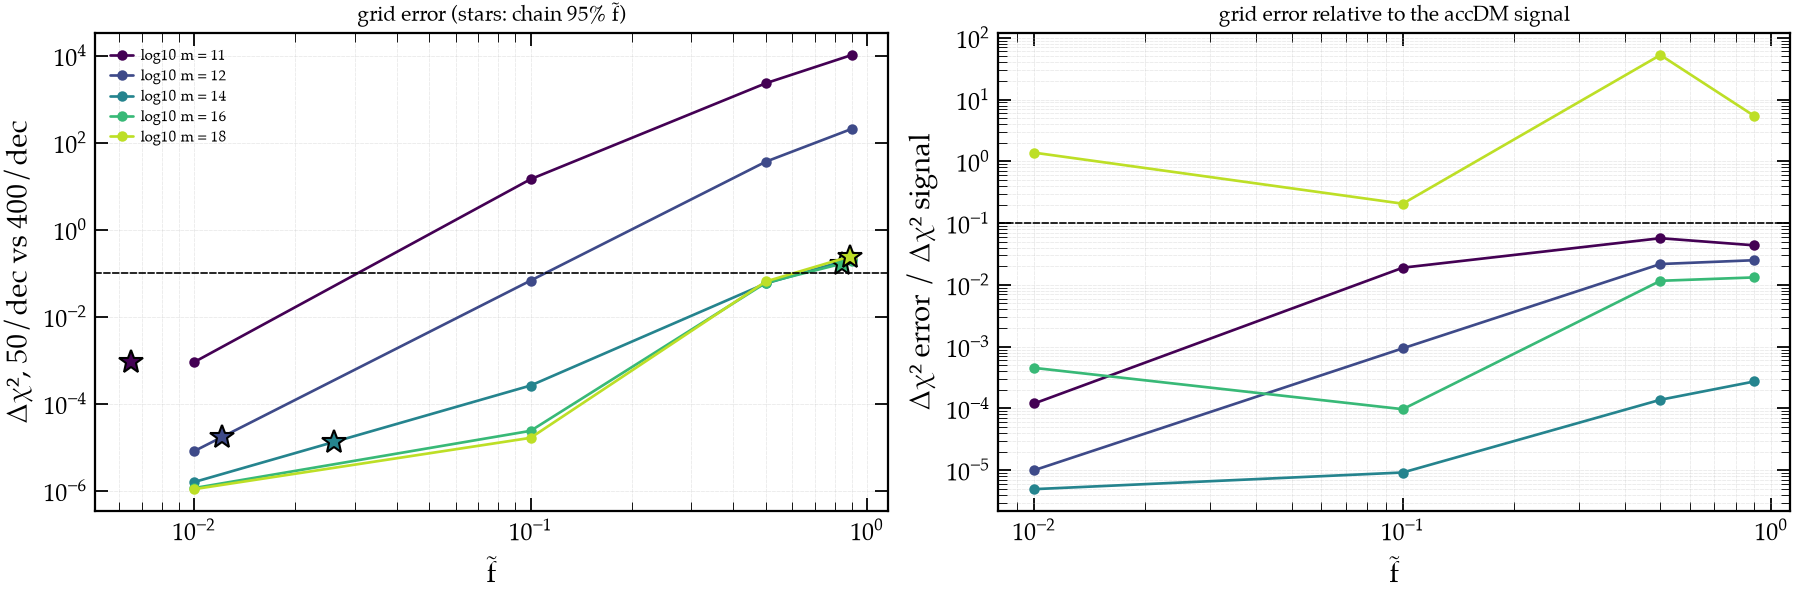

,chain 95% f_tilde,dchi2 50 at f95,signal at f95,extrapolated
log10m,,,,
11,0.007,9.01e-04,7.49e+00,True
12,0.012,1.69e-05,1.17e+00,False
14,0.026,1.32e-05,2.07e+00,False
16,0.844,1.66e-01,1.28e+01,False
18,0.889,2.41e-01,4.26e-02,False


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
rows = []
for c, lm in zip(plt.cm.viridis(np.linspace(0, 0.9, len(MASSES))), MASSES):
    f = np.array(F_GRID)
    d50 = np.array([table.loc[(lm, ft), 'dchi2 50'] for ft in F_GRID])
    sig = np.array([table.loc[(lm, ft), 'signal'] for ft in F_GRID])
    axes[0].loglog(f, d50, 'o-', color=c, ms=4, label='log10 m = {:g}'.format(lm))
    axes[1].loglog(f, d50/sig, 'o-', color=c, ms=4)
    if lm in F95:
        f95 = F95[lm]
        at = np.exp(np.interp(np.log(f95), np.log(f), np.log(d50)))
        axes[0].plot(f95, at, '*', color=c, ms=12, mec='k')
        rows.append({'log10m': lm, 'chain 95% f_tilde': f95, 'dchi2 50 at f95': at,
                     'signal at f95': np.exp(np.interp(np.log(f95), np.log(f), np.log(sig))),
                     'extrapolated': not (f[0] <= f95 <= f[-1])})
for ax in axes:
    ax.axhline(DCHI2_TOL, color='k', ls='--', lw=0.8)
    ax.set_xlabel('f̃')
    ax.grid(alpha=0.3, which='both')
axes[0].set_ylabel('Δχ², 50/dec vs {}/dec'.format(REF))
axes[1].set_ylabel('Δχ² error / Δχ² signal')
axes[0].set_title('grid error (stars: chain 95% f̃)', fontsize=10)
axes[1].set_title('grid error relative to the accDM signal', fontsize=10)
axes[0].legend(fontsize=7)
plt.show()
show(pd.DataFrame(rows).set_index('log10m'),
     {'chain 95% f_tilde': '{:.3f}', 'dchi2 50 at f95': '{:.2e}', 'signal at f95': '{:.2e}'})

## 2. What limits convergence?

At two points (warm daughter at f̃ = 0.5, cold daughter at f̃ = 0.9), the plain sequence from section 1 is
repeated with `accdm_smooth_births = 1` (each bin born gradually across its cell instead of at one instant), and
50/decade is rerun with one change each:

- `tol_perturbations_integration` 10⁻⁵ → 10⁻⁷: integrator error;
- `accdm_q_number_tol` 10⁻⁶ → 10⁻⁹: the a_min cut of early births;
- `l_max_ncdm` 17 → 50: truncation of the daughter's Boltzmann hierarchy.

Everything is compared with plain 400/decade. Smooth 400 vs plain 400 checks that both sequences approach the
same limit. If a single change closes most of the 50/decade error, it names the cause; if smooth births converge
faster, the slow convergence comes from the instantaneous births.

In [7]:
POINTS = [(12, 0.5), (16, 0.9)]
VARIANTS = {'tol_pert 1e-7': {'tol_perturbations_integration': 1e-7},
            'q_tol 1e-9': {'accdm_q_number_tol': 1e-9},
            'l_max_ncdm 50': {'l_max_ncdm': 50}}
mech = {}
for lm, ft in POINTS:
    for n in BINS:
        mech[(lm, ft, 'smooth', n)] = out = cached_run(params(lm, ft, accdm_smooth_births=1, **per_decade(n)))
        print('log10m {:g} f_tilde {:g} smooth {:>4d}/dec {:6.0f} s  {}'.format(
            lm, ft, n, out['sec'], 'ok' if ok(out) else out.get('error', 'NON-FINITE')[-120:]), flush=True)
    for label, extra in VARIANTS.items():
        mech[(lm, ft, label, 50)] = out = cached_run(params(lm, ft, **per_decade(50), **extra))
        print('log10m {:g} f_tilde {:g} {:<14s} 50/dec {:6.0f} s  {}'.format(
            lm, ft, label, out['sec'], 'ok' if ok(out) else out.get('error', 'NON-FINITE')[-120:]), flush=True)

log10m 12 f_tilde 0.5 smooth   50/dec     12 s  ok
log10m 12 f_tilde 0.5 smooth  100/dec     22 s  ok
log10m 12 f_tilde 0.5 smooth  200/dec     44 s  ok
log10m 12 f_tilde 0.5 smooth  400/dec    100 s  ok
log10m 12 f_tilde 0.5 tol_pert 1e-7  50/dec     19 s  ok
log10m 12 f_tilde 0.5 q_tol 1e-9     50/dec     13 s  ok
log10m 12 f_tilde 0.5 l_max_ncdm 50  50/dec     28 s  ok
log10m 16 f_tilde 0.9 smooth   50/dec     17 s  ok
log10m 16 f_tilde 0.9 smooth  100/dec     27 s  ok
log10m 16 f_tilde 0.9 smooth  200/dec     56 s  ok
log10m 16 f_tilde 0.9 smooth  400/dec    115 s  ok
log10m 16 f_tilde 0.9 tol_pert 1e-7  50/dec     20 s  ok
log10m 16 f_tilde 0.9 q_tol 1e-9     50/dec     15 s  ok
log10m 16 f_tilde 0.9 l_max_ncdm 50  50/dec     29 s  ok


In [8]:
rows = []
for lm, ft in POINTS:
    ref = res[(lm, ft, REF)]
    cases = [('plain', n, res[(lm, ft, n)]) for n in BINS] + \
            [('smooth', n, mech[(lm, ft, 'smooth', n)]) for n in BINS] + \
            [(label, 50, mech[(lm, ft, label, 50)]) for label in VARIANTS]
    for label, n, out in cases:
        if not ok(out):
            rows.append({'log10m': lm, 'f_tilde': ft, 'setting': label, 'bins/dec': n})
            continue
        c = compare(out, ref)
        rows.append({'log10m': lm, 'f_tilde': ft, 'setting': label, 'bins/dec': n, 'dchi2': c['total'],
                     'cmb': c['cmb'], 'lens': c['lens'], 'bao': c['bao'], 'max dPcb': c['dpk'],
                     'dsigma8_cb': c['dsigma8'], 'dOmega_acc': c['domega'], 'time [s]': out['sec']})
    for label in ('plain', 'smooth'):
        seq = [(res[(lm, ft, n)] if label == 'plain' else mech[(lm, ft, 'smooth', n)]) for n in BINS[:-1]]
        print('log10m {:g}, f_tilde {:g}, {}: sigma8_cb order {:.1f}'.format(
            lm, ft, label, order(*(o['sigma8_cb'] for o in seq))))
mtab = pd.DataFrame(rows).set_index(['log10m', 'f_tilde', 'setting', 'bins/dec'])
show(mtab, {**{c: '{:.2e}' for c in mtab.columns}, 'dsigma8_cb': '{:+.1e}', 'dOmega_acc': '{:+.1e}',
            'time [s]': '{:.0f}'})

log10m 12, f_tilde 0.5, plain: sigma8_cb order 2.1
log10m 12, f_tilde 0.5, smooth: sigma8_cb order 1.0
log10m 16, f_tilde 0.9, plain: sigma8_cb order 2.1
log10m 16, f_tilde 0.9, smooth: sigma8_cb order 1.0


dchi2       cmb      lens       bao  \
log10m f_tilde setting       bins/dec                                           
12     0.5     plain         50        3.65e+01  3.65e+01  5.31e-02  4.74e-08   
                             100       1.32e+00  1.31e+00  5.55e-03  7.74e-09   
                             200       6.92e-02  5.97e-02  9.48e-03  7.52e-09   
                             400       0.00e+00  0.00e+00  0.00e+00  0.00e+00   
               smooth        50        3.19e+01  3.11e+01  8.14e-01  4.67e-10   
                             100       3.74e+00  3.53e+00  2.09e-01  1.47e-10   
                             200       2.71e-01  2.16e-01  5.48e-02  2.56e-10   
                             400       8.69e-02  7.23e-02  1.46e-02  3.40e-10   
               tol_pert 1e-7 50        3.66e+01  3.65e+01  5.33e-02  4.74e-08   
               q_tol 1e-9    50        2.28e+01  2.27e+01  2.18e-02  1.46e-08   
               l_max_ncdm 50 50        1.40e+01  1.39e+01  4.24e-02  4.74e-08   
16     0.9     plain         50        1.88e-01  1.42e-01  4.69e-02  1.30e-07   
                             100       7.20e-02  5.27e-02  1.94e-02  2.12e-08   
                             200       1.63e-02  1.18e-02  4.52e-03  2.06e-08   
                             400       0.00e+00  0.00e+00  0.00e+00  0.00e+00   
               smooth        50        9.09e-02  5.90e-02  3.20e-02  1.34e-09   
                             100       2.72e-02  1.84e-02  8.79e-03  4.08e-10   
                             200       9.64e-03  7.27e-03  2.37e-03  6.62e-10   
                             400       4.59e-03  3.87e-03  7.21e-04  9.24e-10   
               tol_pert 1e-7 50        1.91e-01  1.44e-01  4.69e-02  1.30e-07   
               q_tol 1e-9    50        1.23e-01  9.33e-02  3.01e-02  4.16e-08   
               l_max_ncdm 50 50        1.92e-01  1.45e-01  4.73e-02  1.30e-07   

                                       max dPcb dsigma8_cb dOmega_acc time [s]  
log10m f_tilde setting       bins/dec                                           
12     0.5     plain         50        1.23e-02   -6.1e-03   +2.0e-07       11  
                             100       3.41e-03   -1.6e-03   -3.2e-11       22  
                             200       1.19e-03   -5.4e-04   -1.9e-12       48  
                             400       0.00e+00   +0.0e+00   +0.0e+00      116  
               smooth        50        2.27e-02   +1.0e-02   +2.0e-07       12  
                             100       1.24e-02   +5.6e-03   -3.2e-11       22  
                             200       7.02e-03   +3.2e-03   -1.9e-12       44  
                             400       4.31e-03   +1.9e-03   +0.0e+00      100  
               tol_pert 1e-7 50        1.23e-02   -6.1e-03   +2.0e-07       19  
               q_tol 1e-9    50        8.42e-03   -4.1e-03   +8.2e-07       13  
               l_max_ncdm 50 50        1.21e-02   +3.5e-05   +2.0e-07       28  
16     0.9     plain         50        3.65e-02   -6.4e-03   +2.0e-07       17  
                             100       9.41e-03   -1.6e-03   -3.2e-11       36  
                             200       3.16e-03   -5.5e-04   -1.9e-12       62  
                             400       0.00e+00   +0.0e+00   +0.0e+00      130  
               smooth        50        4.50e-02   +5.6e-03   +2.0e-07       17  
                             100       2.42e-02   +3.2e-03   -3.2e-11       27  
                             200       1.36e-02   +1.9e-03   -1.9e-12       56  
                             400       8.41e-03   +1.3e-03   +0.0e+00      115  
               tol_pert 1e-7 50        3.65e-02   -6.4e-03   +2.0e-07       20  
               q_tol 1e-9    50        2.40e-02   -4.1e-03   +8.2e-07       15  
               l_max_ncdm 50 50        3.56e-02   -6.3e-03   +2.0e-07       29

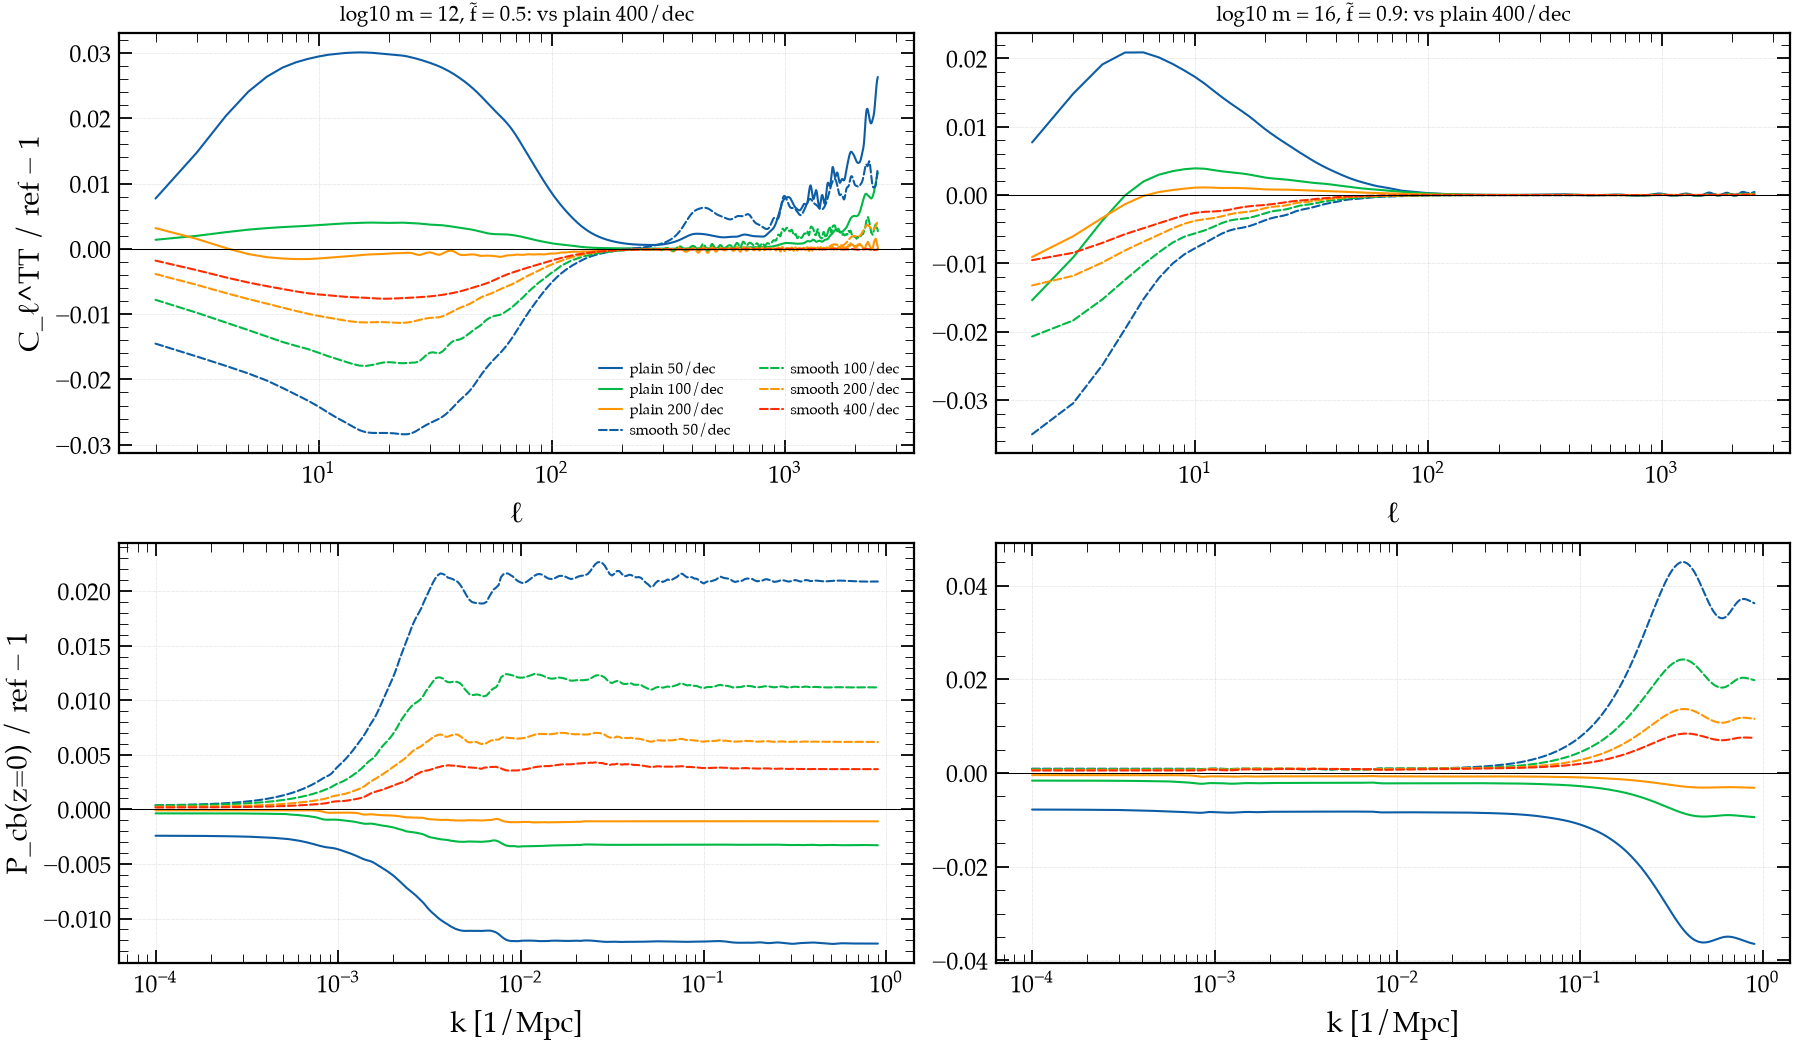

In [9]:
fig, axes = plt.subplots(2, len(POINTS), figsize=(6*len(POINTS), 7), constrained_layout=True, squeeze=False)
for j, (lm, ft) in enumerate(POINTS):
    ref = res[(lm, ft, REF)]
    for label, ls in (('plain', '-'), ('smooth', '--')):
        for c, n in zip(('C0', 'C1', 'C2', 'C3'), BINS):
            out = res[(lm, ft, n)] if label == 'plain' else mech[(lm, ft, 'smooth', n)]
            if (label == 'plain' and n == REF) or not ok(out):
                continue
            kw = dict(color=c, ls=ls, lw=1, label='{} {}/dec'.format(label, n))
            axes[0, j].semilogx(ELL, out['tt']/ref['tt'] - 1, **kw)
            axes[1, j].semilogx(KK, out['pk_cb']/ref['pk_cb'] - 1, **kw)
    axes[0, j].set_title('log10 m = {:g}, f̃ = {:g}: vs plain {}/dec'.format(lm, ft, REF), fontsize=10)
    axes[0, j].set_xlabel('ℓ')
    axes[1, j].set_xlabel('k [1/Mpc]')
    for ax in axes[:, j]:
        ax.axhline(0, color='k', lw=0.5)
        ax.grid(alpha=0.3)
axes[0, 0].set_ylabel('C_ℓ^TT / ref − 1')
axes[1, 0].set_ylabel('P_cb(z=0) / ref − 1')
axes[0, 0].legend(fontsize=7, ncol=2)
plt.show()

### 2b. Is the reference's hierarchy long enough?

At the warm point, `l_max_ncdm = 50` at 50/decade removes the σ8_cb bias, but the 400/decade reference also uses
`l_max_ncdm = 17`. Rerunning 400/decade with `l_max_ncdm = 50` separates the two: its difference from plain 400 is
the reference's own truncation error, and l_max 50 at 50/decade against it is the pure grid error at l_max 50.

In [10]:
for lm, ft in POINTS:
    mech[(lm, ft, 'l_max_ncdm 50', REF)] = cached_run(params(lm, ft, l_max_ncdm=50, **per_decade(REF)))
rows = []
for lm, ft in POINTS:
    long_ref = mech[(lm, ft, 'l_max_ncdm 50', REF)]
    assert ok(long_ref), long_ref.get('error')
    for label, a, b in [('400, l_max 17 vs 400, l_max 50', res[(lm, ft, REF)], long_ref),
                        ('50, l_max 17 vs 400, l_max 50', res[(lm, ft, 50)], long_ref),
                        ('50, l_max 50 vs 400, l_max 50', mech[(lm, ft, 'l_max_ncdm 50', 50)], long_ref)]:
        c = compare(a, b)
        rows.append({'log10m': lm, 'f_tilde': ft, 'comparison': label, 'dchi2': c['total'], 'cmb': c['cmb'],
                     'lens': c['lens'], 'max dPcb': c['dpk'], 'dsigma8_cb': c['dsigma8']})
ltab = pd.DataFrame(rows).set_index(['log10m', 'f_tilde', 'comparison'])
show(ltab, {**{c: '{:.2e}' for c in ltab.columns}, 'dsigma8_cb': '{:+.1e}'})
print('time, 400/dec with l_max_ncdm 50: ' + ', '.join('{:.0f} s'.format(mech[(lm, ft, 'l_max_ncdm 50', REF)]['sec'])
                                                    for lm, ft in POINTS))

dchi2       cmb      lens  \
log10m f_tilde comparison                                                     
12     0.5     400, l_max 17 vs 400, l_max 50  1.97e-01  9.71e-03  1.87e-01   
               50, l_max 17 vs 400, l_max 50   3.69e+01  3.65e+01  4.37e-01   
               50, l_max 50 vs 400, l_max 50   1.40e+01  1.40e+01  5.27e-02   
16     0.9     400, l_max 17 vs 400, l_max 50  8.98e-04  8.96e-04  1.13e-06   
               50, l_max 17 vs 400, l_max 50   1.86e-01  1.40e-01  4.64e-02   
               50, l_max 50 vs 400, l_max 50   1.88e-01  1.42e-01  4.69e-02   

                                               max dPcb dsigma8_cb  
log10m f_tilde comparison                                           
12     0.5     400, l_max 17 vs 400, l_max 50  1.65e-02   -6.1e-03  
               50, l_max 17 vs 400, l_max 50   2.84e-02   -1.2e-02  
               50, l_max 50 vs 400, l_max 50   1.22e-02   -6.1e-03  
16     0.9     400, l_max 17 vs 400, l_max 50  9.18e-04   -5.9e-05  
               50, l_max 17 vs 400, l_max 50   3.74e-02   -6.4e-03  
               50, l_max 50 vs 400, l_max 50   3.65e-02   -6.4e-03

time, 400/dec with l_max_ncdm 50: 357 s, 399 s


## Reading the result

- **Section 0:** the default grid has 71 nodes. Only 17 fall inside the central 98% of births
  (a = 0.091–0.194), and 8 inside the central 80%. 37, half the grid, come after the births are over.
- **Section 1, convergence:** the grid error converges cleanly at second order (σ8_cb order 1.5–2.1 at every
  point). nb36's order-0.7 estimate came from max |ΔC_ℓ^TT| against a 200/decade reference, which was not
  converged itself. The 400/decade reference is good to Δχ² ≤ 0.01 (400 vs 800). The error is smooth and
  systematic: low-ℓ TT (ISW, ℓ ≲ 100), a P_cb offset, and for the warm daughter also high-ℓ TT.
- **Section 1, size:** the error grows steeply with f̃ and is largest for warm daughters. At 50/decade it is
  above Δχ² = 0.1 from f̃ = 0.1 at 10¹¹ GeV, from f̃ = 0.5 at 10¹² GeV, and near f̃ = 0.9 at 10¹⁴–10¹⁸ GeV.
  Wherever accDM is detectable (10¹¹–10¹⁶ GeV) it stays below 6% of the accDM signal.
- **Section 1b, chains:**
  - **Up to 10¹⁵ GeV:** the posteriors stay at f̃ ≲ 0.08 and the grid error there is ≲ 10⁻³, so those limits
    are safe.
  - **10¹⁶ GeV:** the error at the 95% edge (f̃ = 0.84) is 0.17, against a signal of 13 with ΛCDM fixed. The
    limit moves little.
  - **10¹⁸ GeV:** the error at the edge is 0.24, against a signal of only 0.04. What the 10¹⁸ chain sees at
    large f̃ is mostly grid error, not physics. Its f̃ posterior is shaped by numerics: the step at f_acc = 1 in
    nb36 is plausibly this. Physically, accDM is unconstrained there. 10¹⁶·³–10¹⁷·⁷ GeV were not tested and
    probably lie in between.
- **A separate floor:** 3 of the 60 comparisons show Δχ² ≈ 0.04 regardless of bin count (10¹⁸ GeV f̃ = 0.01 at
  100/decade, 10¹⁶ GeV f̃ = 0.1 at 100, 10¹² GeV f̃ = 0.1 at 200). This is the bin-independent jump nb33 also
  saw, unrelated to the grid.
- **Section 2, cause:**
  - The integrator tolerance changes nothing, so the integrator is not the cause.
  - The abundance is right to 2·10⁻⁷ (dΩ_acc), so the error is in the perturbations, not the background.
  - Moving a_min (`accdm_q_number_tol` 10⁻⁹) helps by ~35%, which fits node placement mattering.
  - Smooth births converge only at first order (σ8_cb: 1.0, 0.56, 0.32, 0.19% for 50–400/decade), with the
    opposite sign. They are worse than instantaneous births; keep them off.
  - The error is the resolution of the birth epoch by ~17 nodes.
- **Section 2b, a second error at warm masses:** the daughter hierarchy at `l_max_ncdm = 17` is too short for a
  warm daughter at large f̃. At 10¹² GeV, f̃ = 0.5, it biases σ8_cb by −0.6% (Δχ² 0.2, mostly lensing) at any
  grid. At 10¹⁶ GeV it is negligible (Δχ² 10⁻³). It did not show at the chains' f̃, but it biases warm-daughter
  training points at large f̃. The apparent fix by `l_max_ncdm = 50` in section 2 was two −0.6% errors
  cancelling.

**What to do:** the error is a clean second-order quadrature error from too few nodes in the birth window, while
half the nodes sit after it. Placing nodes by born fraction instead of evenly in ln a should cut the error
amplitude by ~10× and Δχ² by ~100× at the same cost: about three times the nodes in the window, at second order.
This is an estimate to verify. Until then, 200/decade (~4× the cost) brings Δχ² below 0.1 at every point tested
except warm daughters at f̃ ≥ 0.5. For warm masses at large f̃, also raise `l_max_ncdm`.